## RNN Example for Time Series
----
----
## Data
Release: Advance Monthly Sales for Retail and Food Services
Units: Millions of Dollars, Not Seasonally Adjusted

Frequency: Monthly

The value for the most recent month is an advance estimate that is based on data from a subsample of firms from the larger Monthly Retail Trade Survey. The advance estimate will be superseded in following months by revised estimates derived from the larger Monthly Retail Trade Survey. The associated series from the Monthly Retail Trade Survey is available at https://fred.stlouisfed.org/series/MRTSSM448USN

Information about the Advance Monthly Retail Sales Survey can be found on the Census website at https://www.census.gov/retail/marts/about_the_surveys.html

Suggested Citation: U.S. Census Bureau, Advance Retail Sales: Clothing and Clothing Accessory Stores [RSCCASN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RSCCASN, November 16, 2019.

https://fred.stlouisfed.org/series/RSCCASN


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Data\data tensorflow\RSCCASN.csv', index_col='DATE', parse_dates= True)

In [3]:
df.head()

,RSCCASN
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


In [4]:
df.columns =['Sale']

In [5]:
df.head()

,Sale
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 334 entries, 1992-01-01 to 2019-10-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sale    334 non-null    int64
dtypes: int64(1)
memory usage: 5.2 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sale,334.0,16325.095808,5369.839014,6938.0,12298.5,15878.5,19772.5,34706.0


In [8]:
plt.style.use(['science','notebook','grid'])

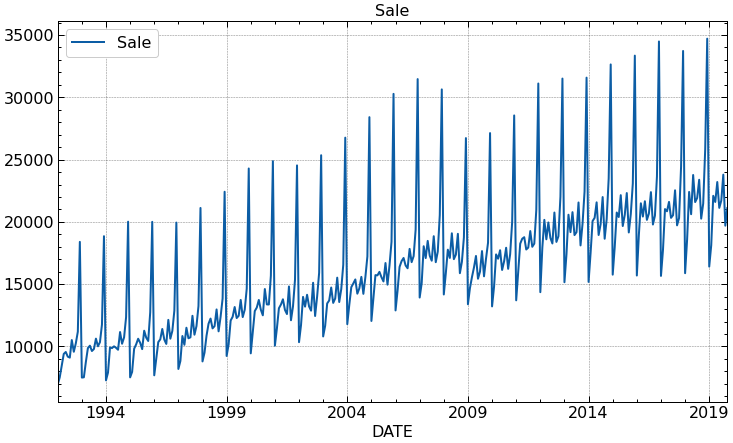

In [9]:
df.plot(figsize=(12, 7), title='Sale');

----
-----
# Train test split
- Mengambil data testing 1.5 tahun atau 18 bulan

In [10]:
len(df)

334

In [11]:
test_point = 18

In [12]:
test_index = len(df) - 18
test_index

316

In [13]:
train = df.iloc[:test_index]
test = df.iloc[test_index:]

In [14]:
train

,Sale
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2017-12-01,33720
2018-01-01,15881
2018-02-01,18585


In [15]:
test

,Sale
DATE,
2018-05-01,23764
2018-06-01,21589
2018-07-01,21919
2018-08-01,23381
2018-09-01,20260
2018-10-01,21473
2018-11-01,25831
2018-12-01,34706
2019-01-01,16410


In [16]:
train.shape, test.shape

((316, 1), (18, 1))

----
----
## Scaler data

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
scaler = MinMaxScaler()

In [19]:
scaler_train = scaler.fit_transform(train)
scaler_test = scaler.transform(test)

--------
--------
## Timeseries Generator

In [20]:
import tensorflow as tf

In [21]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [22]:
help(TimeseriesGenerator)

Help on class TimeseriesGenerator in module keras.preprocessing.sequence:

class TimeseriesGenerator(keras.utils.data_utils.Sequence)
 |  TimeseriesGenerator(data, targets, length, sampling_rate=1, stride=1, start_index=0, end_index=None, shuffle=False, reverse=False, batch_size=128)
 |  
 |  Utility class for generating batches of temporal data.
 |  
 |  Deprecated: `tf.keras.preprocessing.sequence.TimeseriesGenerator` does not
 |  operate on tensors and is not recommended for new code. Prefer using a
 |  `tf.data.Dataset` which provides a more efficient and flexible mechanism for
 |  batching, shuffling, and windowing input. See the
 |  [tf.data guide](https://www.tensorflow.org/guide/data) for more details.
 |  
 |  This class takes in a sequence of data-points gathered at
 |  equal intervals, along with time series parameters such as
 |  stride, length of history, etc., to produce batches for
 |  training/validation.
 |  
 |  Arguments:
 |      data: Indexable generator (such as li

In [23]:
# mendefiniskan 12 bulan sebelumya untuk mendapatkan prediksi bulan berikutnya
length = 12
generator = TimeseriesGenerator(scaler_train, scaler_train, length=length, batch_size=1)

In [24]:
# menampilkan bacth pertam
X, y = generator[0]

In [25]:
print(f'Given the array : {X.flatten()} \n')
print(f'Predict y ; {y}')

Given the array : [0.         0.02127505 0.05580163 0.08942056 0.09512053 0.08146965
 0.07860151 0.12979233 0.09566512 0.1203892  0.15426227 0.41595266] 

Predict y ; [[0.02047633]]


----
---
## Create model

In [26]:
tf.random.set_seed(46)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [28]:
n_features = 1

In [29]:
model = Sequential()

# LSTM layers 
model.add(LSTM(100, input_shape=(length, n_features), activation='relu'))

# output layers
model.add(Dense(1))

# compile model
model.compile(loss='mse', optimizer='adam')

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100)               40800     
                                                                 
 dense (Dense)               (None, 1)                 101       
                                                                 
Total params: 40,901
Trainable params: 40,901
Non-trainable params: 0
_________________________________________________________________


----
## Add Earlystopping and Validation Generator

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

In [32]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

In [33]:
# validation generator
validation_generator = TimeseriesGenerator(scaler_test, scaler_test, length=length, batch_size= 1)

----
----
## Fitting Model

In [34]:
model.fit(generator, epochs = 20,
          validation_data=validation_generator, 
          callbacks =[early_stop])

Epoch 1/20
304/304 [==============================] - 13s 22ms/step - loss: 0.0225 - val_loss: 0.0054
Epoch 2/20
304/304 [==============================] - 5s 17ms/step - loss: 0.0195 - val_loss: 0.0066
Epoch 3/20
304/304 [==============================] - 6s 18ms/step - loss: 0.0100 - val_loss: 0.0029
Epoch 4/20
304/304 [==============================] - 6s 20ms/step - loss: 0.0050 - val_loss: 7.1438e-04
Epoch 5/20
304/304 [==============================] - 6s 20ms/step - loss: 0.0025 - val_loss: 4.5105e-04
Epoch 6/20
304/304 [==============================] - 6s 19ms/step - loss: 0.0018 - val_loss: 3.7200e-04
Epoch 7/20
304/304 [==============================] - 6s 19ms/step - loss: 0.0021 - val_loss: 0.0028
Epoch 8/20
304/304 [==============================] - 6s 20ms/step - loss: 0.0015 - val_loss: 4.6716e-04


In [35]:
losses = pd.DataFrame(model.history.history)

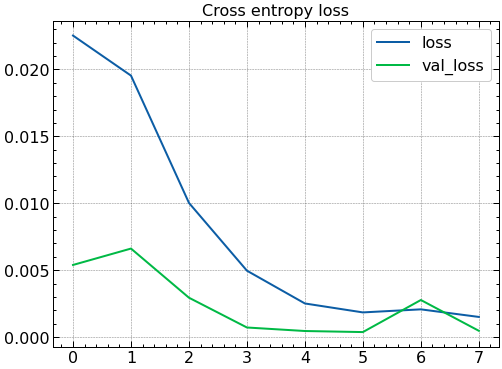

In [36]:
losses.plot(title='Cross entropy loss');

---
---
## Evaluation on test data

In [37]:
test_prediction = []
first_evaluation_batch = scaler_train[-length:]
current_batch = first_evaluation_batch.reshape((1, length, n_features))

for i in range(len(test)):
    
    # get predict
    current_pred = model.predict(current_batch)[0]
    
    # store prediction
    test_prediction.append(current_pred)
    
    # update batch
    current_batch = np.append(current_batch[:, 1:,:], [[current_pred]], axis=1)

1/1 [==============================] - 0s 64ms/step


----
## Inverse transform and Compire

In [38]:
true_prediction = scaler.inverse_transform(test_prediction)

In [39]:
true_prediction

array([[20820.56860161],
       [19860.6314342 ],
       [20104.78269362],
       [21746.0938611 ],
       [19493.73717356],
       [20095.39598608],
       [23813.17738152],
       [34301.83760166],
       [16225.46866179],
       [18308.92207479],
       [21456.40865612],
       [19977.80151391],
       [20204.99759674],
       [19520.10450482],
       [19769.27459502],
       [21074.09425545],
       [19319.80932212],
       [19909.97998667]])

In [40]:
test['Prediction'] = true_prediction

C:\Users\ibrahim\AppData\Local\Temp\ipykernel_8268\249045001.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prediction'] = true_prediction


In [41]:
test

,Sale,Prediction
DATE,,
2018-05-01,23764,20820.568602
2018-06-01,21589,19860.631434
2018-07-01,21919,20104.782694
2018-08-01,23381,21746.093861
2018-09-01,20260,19493.737174
2018-10-01,21473,20095.395986
2018-11-01,25831,23813.177382
2018-12-01,34706,34301.837602
2019-01-01,16410,16225.468662


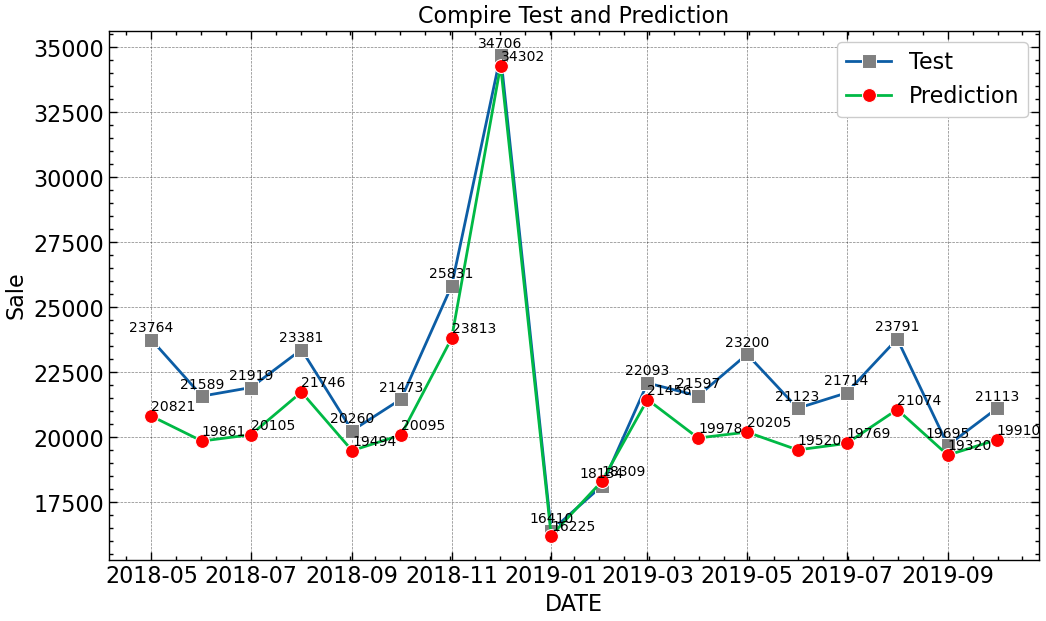

In [42]:
plt.figure(figsize=(12, 7), dpi=100)

sns.lineplot(x=test.index, y ='Sale', data=test, marker='s', markerfacecolor='gray', markersize=10, label='Test')

for y,x in zip(test['Sale'], test.index):
    plt.text(x = x ,
         y = y+300, 
         s = '{:.0f}'.format(y),
         ha = 'center'           
        )
    
sns.lineplot(y='Prediction', x= test.index, data=test, marker='o', markerfacecolor='red', markersize=10,label='Prediction')
for y,x in zip(test['Prediction'], test.index):
    plt.text(x = x,
         y = y+200, 
         s = '{:.0f}'.format(y),
         ha = 'left'
        )
plt.legend();
plt.title('Compire Test and Prediction');

`Kesimpulan :` Hasil perbandingan antara data test dengan data prediksi mempunyai pola yang serupa hanya saja dari prediksi ada penurunan penjualan di masing-masing bulan pada tahun 2018 - 2019

----
----
## Retrain and Forecase full data

In [43]:
# scaler 
full_scaler = MinMaxScaler()

In [44]:
# scaler full data
full_data_scaler = full_scaler.fit_transform(df)

In [45]:
length = 12
generator = TimeseriesGenerator(full_data_scaler, full_data_scaler , length=length, batch_size=1)

In [46]:
# model
model = Sequential()
model.add(LSTM(100, input_shape=(length, n_features), activation ='relu'))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')

In [47]:
model.fit(generator, epochs=8)

Epoch 1/8
322/322 [==============================] - 11s 16ms/step - loss: 0.0263
Epoch 2/8
322/322 [==============================] - 6s 18ms/step - loss: 0.0172
Epoch 3/8
322/322 [==============================] - 6s 19ms/step - loss: 0.0131
Epoch 4/8
322/322 [==============================] - 6s 19ms/step - loss: 0.0044
Epoch 5/8
322/322 [==============================] - 6s 20ms/step - loss: 0.0022
Epoch 6/8
322/322 [==============================] - 6s 18ms/step - loss: 0.0023
Epoch 7/8
322/322 [==============================] - 6s 19ms/step - loss: 0.0014
Epoch 8/8
322/322 [==============================] - 7s 20ms/step - loss: 0.0018


In [48]:
# evaluasi dan prediksi

forecase = []
periods = 12

first_evaluation_batch =  full_data_scaler[-length:]
current_batch = first_evaluation_batch.reshape((1, length, n_features)) 

for i in range(periods):
    # current predictions
    current_pred = model.predict(current_batch)[0]
    # store prediction
    forecase.append(current_pred)
    # update bacth | prediction | drop first values
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis =1)

1/1 [==============================] - 0s 78ms/step


In [49]:
# inverse trasform
forecase = scaler.inverse_transform(forecase)

In [50]:
forecase

array([[23933.32067108],
       [32427.08841658],
       [15702.46939135],
       [17265.42391968],
       [20357.30113363],
       [20037.42413998],
       [21344.18517017],
       [19696.66736555],
       [20193.54392552],
       [21814.24127579],
       [18667.55586863],
       [19849.72118235]])

## Create new Timestamp index

In [51]:
df

,Sale
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2019-06-01,21123
2019-07-01,21714
2019-08-01,23791


In [52]:
df.tail()

,Sale
DATE,
2019-06-01,21123
2019-07-01,21714
2019-08-01,23791
2019-09-01,19695
2019-10-01,21113


## Pandas frequency string
https://stackoverflow.com/questions/35339139/where-is-the-documentation-on-pandas-freq-tags

https://pandas.pydata.org/docs/user_guide/timeseries.html

**``MS``**       month start frequency


In [53]:
forcase_index = pd.date_range(start='2018-12-01', periods = periods, freq= 'MS')

In [54]:
forecase_df = pd.DataFrame(data=forecase, index= forcase_index , columns=['Forecase'])

In [55]:
forecase_df 

,Forecase
2018-12-01,23933.320671
2019-01-01,32427.088417
2019-02-01,15702.469391
2019-03-01,17265.423920
2019-04-01,20357.301134
2019-05-01,20037.424140
2019-06-01,21344.185170
2019-07-01,19696.667366
2019-08-01,20193.543926
2019-09-01,21814.241276


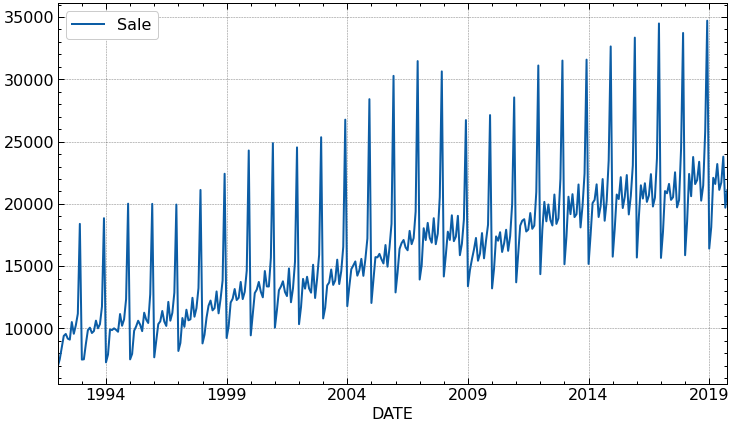

In [56]:
df.plot(figsize=(12,7));

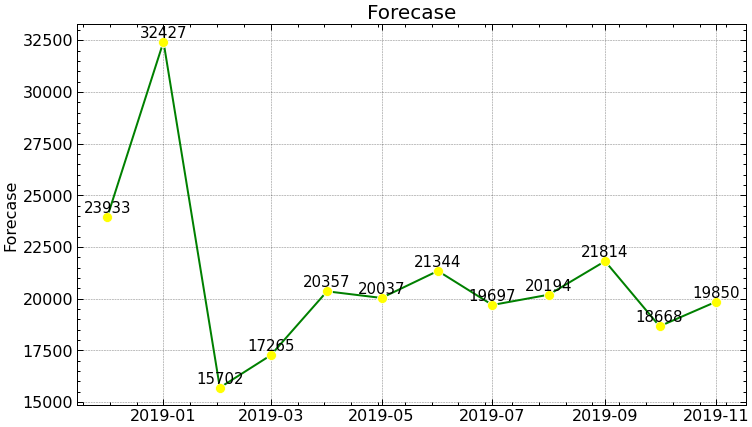

In [57]:
plt.figure(figsize=(12, 7))
sns.lineplot(x=forcase_index, y='Forecase', data=forecase_df, marker='o', markerfacecolor='yellow', markersize=10, color='green')

for x, y in zip(forecase_df.index, forecase_df['Forecase']):
    plt.text(x = x,
             y = y+200, 
             s = '{:.0f}'.format(y),
             ha = 'center',
             size= 15)
plt.title('Forecase', size=20)
plt.show()    

## Joint plot

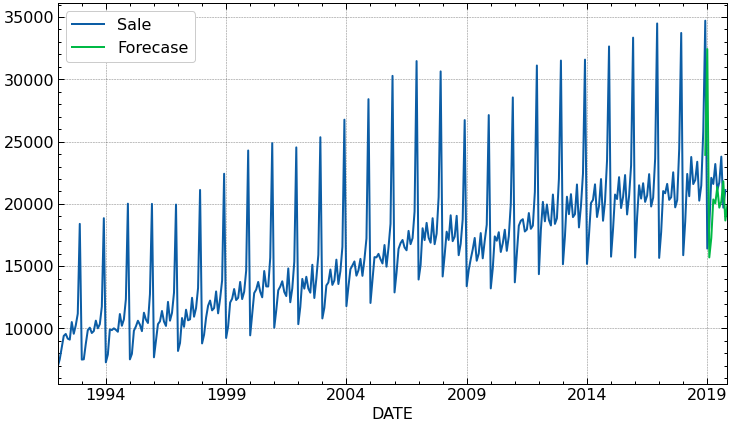

In [58]:
ax = df.plot(figsize=(12, 7))
forecase_df.plot(ax =ax);

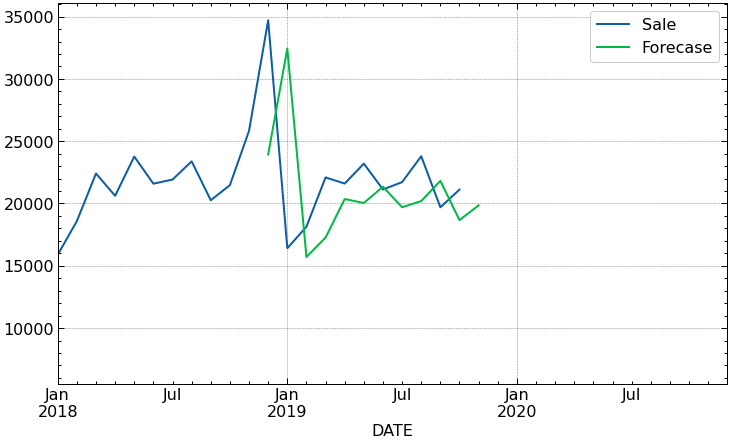

In [59]:
ax = df.plot(figsize=(12, 7))
forecase_df.plot(ax =ax);
plt.xlim('2018-01-01', '2020-12-01');

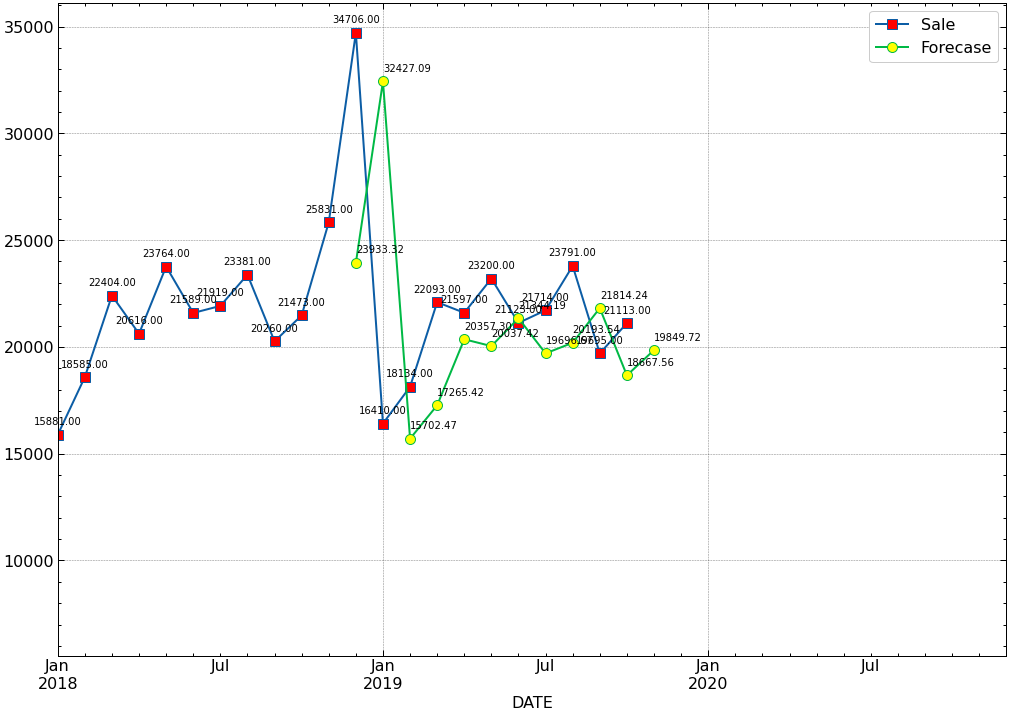

In [60]:

ax = df.plot(figsize=(17, 12),marker='s', markerfacecolor='red', markersize=10)
forecase_df.plot(ax =ax,  marker='o', markerfacecolor='yellow', markersize=10);
plt.xlim('2018-01-01', '2020-12-01');
for x,y in zip(df.index, df['Sale']):

    label = "{:.2f}".format(y)

    plt.annotate(label, # this is the text
                 (x,y), # these are the coordinates to position the label
                 textcoords="offset points", # how to position the text
                 xytext=(0,10), # distance from text to points (x,y)
                 ha='center') # horizontal alignment can be left, right or center
    
    

for x,y in zip(forecase_df.index, forecase_df['Forecase']):

    label = "{:.2f}".format(y)

    plt.annotate(label, # this is the text
                 (x,y), # these are the coordinates to position the label
                 textcoords="offset points", # how to position the text
                 xytext=(0,10), # distance from text to points (x,y)
                 ha='left') # horizontal alignment can be left, right or center
plt.show()


**`Keimpulan  :`** Hasil pembuatan model dari kasus Sales for Retail and Food Services bahwa
- Model prediksi atau forecase pada tahun 2019 sampai 2022 mengalami penurunan dalam penjualan yang biasanya di bulan desember mengalami peningkatan penjualan ada event natal, black firday dan menjelang tahun baru
- Data original di tahun 2018 sampai 2019 mengalami peningkatan penjualan di bulan Desember sebesar `34706` 
- Penurunan penuala 